# Parte 1: Il problema della distribuzione delle chiavi nella crittografia simmetrica

1. L'assunto nascosto della crittografia simmetrica: le chiavi sono **già condivise**.
2. La soluzione ingenua (una chiave per ogni coppia di peer) e la sua **esplosione combinatoria**.
3. Si può usare la *sola* crittografia simmetrica per generare un segreto condiviso su un canale insicuro? Sì (**Merkle Puzzles**), ma con prestazioni pessime.


In [16]:
import os, time, itertools, random
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider
from utils import *

random.seed(42)
print("=" * 70)
print("Ambiente pronto.")
print("=" * 70)

Ambiente pronto.


# 1. Recall on Symmetric Cryptography

```
                         canale INSICURO (Eve puo' leggere tutto qui)
                     ┌────────────────────────────────────────────────┐
                     │                                                │
   Alice             │                                                │             Bob
┌──────────┐    ┌────┴─────┐             ciphertext C           ┌─────┴────┐    ┌──────────┐
│ messaggio│──▶│  Encrypt │──────────────────────────────────▶│  Decrypt │──▶│ messaggio│
│    M     │    │  E(K, M) │                                    │  D(K, C) │    │    M     │
└──────────┘    └────┬─────┘                                    └─────┬────┘    └──────────┘
                     │                                                │
                     └─────────────────────  K  ──────────────────────┘

```

- $K$ must be **known in advance** from both communicating parties because non passa sul canale insicuro
- The secrecy of the scheme rely on the secrecy of the key 
- How the communicating parties obtain that key 



## 2. Key Distribution

Questo problema e' noto come distribuzione delle chiavi e gli approcci sono:

- precondivisione manuale
- meccanismi autoamtici

### Pairwise 

L'idea più semplice: ogni coppia di persone che potrebbe voler comunicare si scambia una chiave *una tantum*, magari di persona, in anticipo (es. su una chiavetta USB, a voce).  
Questo implica che con $N$ nodi nella rete il numero di chiavi necessarie e' pari a:

$$\binom{N}{2} = \frac{N(N-1)}{2}$$

Con $N$ peer nella rete, quante
chiavi servono in totale, se ognuno vuole poter parlare con chiunque altro?


In [24]:
for n in [2, 5, 10, 50, 100, 1000, 10000]:
    print(f"N = {n:>5} peer  ->  {num_pairwise_keys(n):>10} chiavi pre-condivise necessarie")

N =     2 peer  ->           1 chiavi pre-condivise necessarie
N =     5 peer  ->          10 chiavi pre-condivise necessarie
N =    10 peer  ->          45 chiavi pre-condivise necessarie
N =    50 peer  ->        1225 chiavi pre-condivise necessarie
N =   100 peer  ->        4950 chiavi pre-condivise necessarie
N =  1000 peer  ->      499500 chiavi pre-condivise necessarie
N = 10000 peer  ->    49995000 chiavi pre-condivise necessarie


### Interactive representation


In [25]:
interact(draw_peer_key_graph, n=IntSlider(value=8, min=2, max=40, step=1, description="N peer"));

interactive(children=(IntSlider(value=8, description='N peer', max=40, min=2), Output()), _dom_classes=('widge…

**Takeaway**: 

- La pre-condivisione pairwise funziona per un piccolo gruppo statico (es. due server che si parlano da sempre)
- Per reti aperte o dinamiche (internet, reti IoT) questo approccio e' impensabile

Serve un modo per **generare** un segreto condiviso al momento, su un canale che l'attaccante può ascoltare.


### 3. Si può fare key exchange con la sola crittografia simmetrica? Merkle Puzzles

- **Reference**: "[*Secure communications over insecure channels*](https://dl.acm.org/doi/10.1145/359460.359473)"

**Idea (Merkle, 1974)**: Alice prepara $N$ "puzzle": ciascuno è una chiave di sessione cifrata con una
chiave-puzzle volutamente debole (pochi bit). Li invia tutti a Bob, in chiaro, sul canale insicuro. Bob ne
sceglie uno a caso e lo rompe per forza bruta (costo $O(K)$, con $K$ = spazio delle chiavi-puzzle). Da quel
momento Alice e Bob condividono la chiave di sessione contenuta in quel puzzle — **senza essersi mai
incontrati prima**, e usando solo un cifrario simmetrico.

**Il punto cruciale**: un attaccante Eve, per trovare la STESSA chiave di sessione che useranno Alice e
Bob, deve nel caso peggiore rompere tutti gli $N$ puzzle: costo $O(N \cdot K)$. Con $K \approx N$
(dimensionamento tipico), il costo di Eve è $O(N^2)$ contro l'$O(N)$ di Bob: un gap **quadratico**.


In [26]:

def make_puzzles(n_puzzles, key_bits):
    """Alice genera n_puzzles puzzle. Ognuno cela una chiave di sessione dietro
    una chiave-puzzle debole a key_bits bit, cifrata con AES-ECB (va bene per la demo:
    qui vogliamo solo mostrare il costo di brute force, non la sicurezza di AES)."""
    puzzles, session_keys = [], []
    for i in range(n_puzzles):
        weak_key = random.getrandbits(key_bits).to_bytes(16, 'big')
        session_key = os.urandom(16)
        plaintext = pad(b"PUZZLE#" + i.to_bytes(4, 'big') + session_key, 16)
        ct = AES.new(weak_key, AES.MODE_ECB).encrypt(plaintext)
        puzzles.append(ct)
        session_keys.append(session_key)
    return puzzles, session_keys

def try_open(ct, guess_key_int):
    k = guess_key_int.to_bytes(16, 'big')
    try:
        pt = unpad(AES.new(k, AES.MODE_ECB).decrypt(ct), 16)
    except Exception:
        return None
    return pt if pt.startswith(b"PUZZLE#") else None

def bob_solves(puzzles, key_bits):
    """Bob sceglie UN puzzle a caso e lo rompe per forza bruta: costo atteso O(2^key_bits / 2)."""
    idx = random.randrange(len(puzzles))
    for guess in range(2**key_bits):
        pt = try_open(puzzles[idx], guess)
        if pt is not None:
            return idx, pt[11:], guess + 1
    return None, None, None

def eve_breaks_all(puzzles, key_bits):
    """Eve non sa quale puzzle useranno: nel caso peggiore deve romperli tutti."""
    attempts = 0
    for ct in puzzles:
        for guess in range(2**key_bits):
            attempts += 1
            if try_open(ct, guess) is not None:
                break
    return attempts

KEY_BITS = 14  # piccolo apposta per farlo girare in aula in pochi secondi
N_PUZZLES = 6
puzzles, keys = make_puzzles(N_PUZZLES, KEY_BITS)
idx, session_key, bob_attempts = bob_solves(puzzles, KEY_BITS)
print(f"Bob ha aperto il puzzle #{idx} in {bob_attempts} tentativi.")
print("Chiave di sessione condivisa correttamente (Alice e Bob, mai incontrati prima):",
      session_key == keys[idx])


Bob ha aperto il puzzle #4 in 12136 tentativi.
Chiave di sessione condivisa correttamente (Alice e Bob, mai incontrati prima): True


In [27]:
t0 = time.time()
eve_attempts = eve_breaks_all(puzzles, KEY_BITS)
t1 = time.time()
print(f"Eve ha dovuto fare {eve_attempts} tentativi in totale ({t1 - t0:.2f}s) "
      f"contro i ~{2**KEY_BITS // 2} attesi di Bob per un solo puzzle.")


Eve ha dovuto fare 53876 tentativi in totale (0.40s) contro i ~8192 attesi di Bob per un solo puzzle.


### Quanto serve alzare i parametri per rendere la vita difficile a Eve?


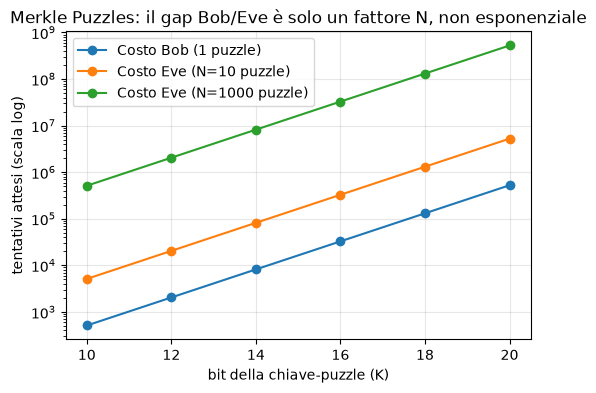

Per dare a Eve un costo di ~2^40 con K=20 bit, servono N = 2e+06 puzzle:
Alice dovrebbe INVIARE quel numero di puzzle sul canale. Non è praticabile.


In [28]:
Ks = [10, 12, 14, 16, 18, 20]
bob_cost = [2**k / 2 for k in Ks]              # per puzzle, un solo tentativo di Bob
eve_cost_N10 = [10 * (2**k / 2) for k in Ks]   # con N=10 puzzle, caso peggiore di Eve
eve_cost_N1000 = [1000 * (2**k / 2) for k in Ks]  # con N=1000 puzzle

plt.figure(figsize=(6,4))
plt.plot(Ks, bob_cost, marker='o', label="Costo Bob (1 puzzle)")
plt.plot(Ks, eve_cost_N10, marker='o', label="Costo Eve (N=10 puzzle)")
plt.plot(Ks, eve_cost_N1000, marker='o', label="Costo Eve (N=1000 puzzle)")
plt.yscale('log')
plt.xlabel("bit della chiave-puzzle (K)")
plt.ylabel("tentativi attesi (scala log)")
plt.title("Merkle Puzzles: il gap Bob/Eve è solo un fattore N, non esponenziale")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"Per dare a Eve un costo di ~2^40 con K=20 bit, servono N = {2**40 / (2**20/2):.0e} puzzle:")
print("Alice dovrebbe INVIARE quel numero di puzzle sul canale. Non è praticabile.")


**Takeaway di questo file**: abbiamo due strade, entrambe con problemi seri:

1. **Pre-condivisione pairwise**: nessuna crittografia asimmetrica richiesta, ma esplosione combinatoria
   $O(N^2)$ nel numero di chiavi da generare/distribuire/custodire.
2. **Merkle Puzzles**: nessuna pre-condivisione richiesta, ma il gap di sicurezza tra il legittimo
   possessore del segreto ed un attaccante è solo *quadratico* — per essere sicuro, il traffico scambiato
   deve crescere enormemente.

In entrambi i casi, il problema di fondo è lo stesso: **con la sola crittografia simmetrica non esiste un
modo efficiente per instaurare un segreto condiviso tra due parti che non si sono mai incontrate**. Nel
prossimo file vedremo perché serve un oggetto matematico diverso — una **funzione trapdoor** — e come RSA
la realizzi, ottenendo finalmente un gap di sicurezza esponenziale invece che quadratico.
